# Sequence to sequence with attention

### One vector cannot hold a long sentence, and here is the length where it stops trying

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The encoder-decoder shape and where its fixed-size bottleneck is, additive attention written from scratch with the scores, weights and context vector all visible, a length sweep that finds where the bottleneck model breaks and whether attention holds, alignment matrices read as pictures and then scored as numbers, and the gap between teacher-forced and free-running evaluation that most reported numbers quietly hide |
| **You should already know** | [GRU](../05-gru/) and [LSTM](../04-lstm/). The encoder and decoder here are both GRUs |
| **Dataset** | A synthetic reverse-copy task generated in the notebook, at six source lengths |
| **Runtime** | Four to five minutes on a laptop CPU |
| **Next** | [09-07 The Transformer, built from scratch](../07-transformer-from-scratch/) |

---

## 1. The idea

Everything recurrent so far read a sequence and produced one thing: a next-hour
forecast, a class label. Translation is not that shape. A sequence goes in, a
different sequence comes out, and the two have different lengths and different
vocabularies.

The 2014 answer, from Sutskever's group and from Cho's independently, is two
recurrent networks bolted together. The **encoder** reads the source and its final
hidden state is handed to the **decoder**, which generates the output one token at
a time, each token conditioned on the state and on what it just emitted.

Look at what that final hidden state has to do. It is a fixed-length vector, a
few hundred numbers, and it has to hold everything about the source that the
decoder will ever need. A three-word source and a forty-word source both get the
same number of numbers. Bahdanau, Cho and Bengio put it plainly in 2015: this
is a bottleneck, and they predicted the model would degrade as the source got
longer.

Their fix is **attention**. Keep every encoder state, not only the last one. At
each decoding step, let the decoder look back over all of them and take a
weighted average, with the weights computed fresh at that step. The source stops
being one vector and becomes a small addressable memory whose size grows with
the sentence.

This notebook builds both, on a task where I know in advance what the right
alignment looks like, so the attention weights can be checked against it rather
than admired. The measurement that carries the chapter is a sweep over source
length, looking for where the bottleneck model starts to fail and whether the
attention model follows it down.

In [1]:
import sys
import time
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cuda


### The task

**Reverse the source.** The input is a sequence of symbols and the output is the
same symbols in the opposite order.

Three reasons this is the right toy problem for this chapter, and one caveat.

It has a known correct alignment. When the decoder emits its first token it
should be looking at the last source position, and at the second token the
second-to-last, so the attention matrix of a working model has to be an
anti-diagonal. That turns "does attention learn something sensible" from a
matter of taste into a comparison against a known answer, which section 6
scores.

Every source position matters equally. Nothing can be skimmed, ignored, or
guessed from a language model over the output, because the symbols are drawn
uniformly at random. A model that gets a token right has genuinely retrieved it.

And it is the worst case for the bottleneck. The decoder needs the *whole*
source, in reverse order, which is exactly the information a single summary
vector has the least room for.

The caveat: every sequence in a given experiment has the same length, so there
is no padding, no end-of-sequence symbol and no masking here. Those three are
most of the fiddly work in a real translation pipeline and none of them is what
this chapter is about. The decoder is run for exactly as many steps as the
source is long.

In [2]:
BOS = 0                 # the token fed to the decoder before it has produced anything
N_SYMBOLS = 8
VOCAB = N_SYMBOLS + 1   # BOS plus the content symbols, which are 1 .. N_SYMBOLS


def make_reverse_task(n, length, rng):
    """Source of `length` random symbols; target is the source reversed."""
    source = rng.integers(1, N_SYMBOLS + 1, size=(n, length)).astype(np.int64)
    target = source[:, ::-1]
    # Teacher forcing feeds the previous *correct* token, so the decoder's input
    # is the target shifted right by one, with BOS in front.
    decoder_input = np.concatenate(
        [np.full((n, 1), BOS, dtype=np.int64), target[:, :-1]], axis=1)
    return source, np.ascontiguousarray(decoder_input), np.ascontiguousarray(target)


demo_rng = np.random.default_rng(SEED)
demo_src, demo_in, demo_out = make_reverse_task(3, 6, demo_rng)
print("source          ", demo_src[0])
print("decoder input   ", demo_in[0], "  (BOS, then the target shifted right)")
print("decoder target  ", demo_out[0])
print(f"\nvocabulary: {VOCAB} tokens, of which {N_SYMBOLS} are content")
print(f"chance of a token by guessing: {1 / N_SYMBOLS:.3f}")

source           [7 6 5 3 3 1]
decoder input    [0 1 3 3 5 6]   (BOS, then the target shifted right)
decoder target   [1 3 3 5 6 7]

vocabulary: 9 tokens, of which 8 are content
chance of a token by guessing: 0.125


## 2. The two architectures, which differ by one line

Both models are the same object with one substitution, and keeping them that
close is what makes the comparison mean anything.

The **encoder** is a GRU over the embedded source. It returns a state for every
source position, $s_1 \ldots s_L$, and its final state $s_L$.

The **decoder** is a GRU cell run in a Python loop, because step $t$ needs the
token produced at step $t-1$ and no library can fuse that. At every step it is
handed the embedding of the previous token and a **context vector** $c_t$, and
from its new state and that context it produces the logits over the vocabulary.

The one line that differs is where $c_t$ comes from.

**Without attention**, $c_t = s_L$ at every step. One vector, computed once,
reused for the whole output. Note that this is the generous version of the
bottleneck model: the summary is fed in at every step rather than only used to
initialise the decoder, so nothing here is losing the source through state decay.
If it fails, it fails because one vector was not enough.

**With attention**, $c_t$ is recomputed at every step as a weighted average of
all the encoder states,

$$e_{tj} = v^\top \tanh\!\left(W_d h_{t-1} + W_e s_j\right), \qquad
\alpha_{tj} = \frac{\exp(e_{tj})}{\sum_{k} \exp(e_{tk})}, \qquad
c_t = \sum_j \alpha_{tj} \, s_j$$

This is Bahdanau's **additive** scoring: project the decoder's state and each
encoder state into a shared space, add them, squash, and read off one score with
a learned vector $v$. The softmax turns the $L$ scores into weights that are
positive and sum to one, so $c_t$ is a convex combination of encoder states and
cannot go anywhere they are not.

Two things about that formula are worth noticing before it becomes code.

$W_e s_j$ does not depend on $t$, so it is computed once for the whole sequence
before the decoding loop starts. Doing it inside the loop is the most common way
to make an attention implementation needlessly slow.

And $\alpha_t$ is a probability distribution over source positions, which is why
it can be plotted as a picture and why the picture is interpretable. Nothing
forces it to concentrate. A model that has not learned anything will produce a
flat distribution, and section 6 measures how flat.

The alternative to additive scoring is Luong's **dot product**,
$e_{tj} = h_{t-1}^\top s_j$, which has no parameters at all and is what the
Transformer in [09-07](../07-transformer-from-scratch/) uses, scaled by
$\sqrt{d}$. I use the additive form here because it is the one the attention
paper introduced and because writing $v$, $W_d$ and $W_e$ out makes the
mechanism harder to skip over.

In [3]:
class Seq2Seq(nn.Module):
    """Encoder-decoder with a switch for where the context vector comes from."""

    def __init__(self, vocab=VOCAB, emb=32, hidden=128, attn_dim=64, attention=True):
        super().__init__()
        self.attention = attention
        self.hidden = hidden
        self.embed = nn.Embedding(vocab, emb)
        self.encoder = nn.GRU(emb, hidden, batch_first=True)
        # The decoder reads the previous token and the context side by side.
        self.cell = nn.GRUCell(emb + hidden, hidden)
        self.out = nn.Linear(2 * hidden, vocab)
        if attention:
            self.W_enc = nn.Linear(hidden, attn_dim, bias=False)
            self.W_dec = nn.Linear(hidden, attn_dim, bias=False)
            self.v = nn.Linear(attn_dim, 1, bias=False)

    def encode(self, source):
        states, last = self.encoder(self.embed(source))
        return states, last[0]              # (B, L, H) and (B, H)

    def score(self, projected_states, h):
        """Additive attention. `projected_states` is W_e s_j, computed once."""
        energy = torch.tanh(projected_states + self.W_dec(h).unsqueeze(1))
        return self.v(energy).squeeze(-1)   # (B, L), one score per source position

    def forward(self, source, decoder_input=None, steps=None):
        """Teacher forcing when `decoder_input` is given, free running otherwise."""
        states, summary = self.encode(source)
        projected = self.W_enc(states) if self.attention else None
        h = summary
        n_steps = decoder_input.shape[1] if decoder_input is not None else steps
        token = torch.full((source.shape[0],), BOS, dtype=torch.long,
                           device=source.device)

        logits_per_step, weights_per_step = [], []
        for t in range(n_steps):
            previous = decoder_input[:, t] if decoder_input is not None else token
            if self.attention:
                alpha = torch.softmax(self.score(projected, h), dim=1)
                context = torch.bmm(alpha.unsqueeze(1), states).squeeze(1)
                weights_per_step.append(alpha)
            else:
                context = summary          # the same vector at every single step
            h = self.cell(torch.cat([self.embed(previous), context], dim=1), h)
            logits = self.out(torch.cat([h, context], dim=1))
            logits_per_step.append(logits)
            token = logits.argmax(dim=1)   # only used when free running

        attention_map = (torch.stack(weights_per_step, dim=1) if self.attention
                         else None)
        return torch.stack(logits_per_step, dim=1), attention_map

### The attention weights, checked by hand

Before training anything, three properties the softmax is supposed to guarantee.
They are cheap to verify and each of them is a claim the figures later depend on.

In [4]:
torch.manual_seed(SEED)
probe = Seq2Seq(attention=True).to(device)
probe_rng = np.random.default_rng(SEED)
probe_src, probe_in, _ = make_reverse_task(4, 7, probe_rng)
probe_src_t = torch.tensor(probe_src).to(device)
probe_in_t = torch.tensor(probe_in).to(device)

with torch.no_grad():
    states, summary = probe.encode(probe_src_t)
    scores = probe.score(probe.W_enc(states), summary)
    alpha = torch.softmax(scores, dim=1)
    context = torch.bmm(alpha.unsqueeze(1), states).squeeze(1)
    logits, attention_map = probe(probe_src_t, probe_in_t)

print(f"encoder states {tuple(states.shape)}  scores {tuple(scores.shape)}  "
      f"weights {tuple(alpha.shape)}")
print(f"weights sum to one            : max deviation "
      f"{(alpha.sum(1) - 1).abs().max():.2e}")
print(f"weights are non-negative      : minimum {alpha.min():.3e}")
print(f"context is a convex average   : its norm {context.norm(dim=1).mean():.3f}, "
      f"largest encoder state norm {states.norm(dim=2).max():.3f}")
print(f"attention map from the forward pass {tuple(attention_map.shape)} "
      f"= (batch, decode steps, source positions)")
print(f"logits {tuple(logits.shape)}")
print(f"\nan untrained model's weights over {probe_src.shape[1]} source positions, "
      f"first example:")
print(np.round(attention_map[0, 0].cpu().numpy(), 3),
      f"  uniform would be {1 / probe_src.shape[1]:.3f}")

encoder states (4, 7, 128)  scores (4, 7)  weights (4, 7)
weights sum to one            : max deviation 0.00e+00
weights are non-negative      : minimum 1.287e-01
context is a convex average   : its norm 1.111, largest encoder state norm 2.621
attention map from the forward pass (4, 7, 7) = (batch, decode steps, source positions)
logits (4, 7, 9)

an untrained model's weights over 7 source positions, first example:
[0.143 0.15  0.16  0.142 0.132 0.136 0.137]   uniform would be 0.143


The context vector's norm is bounded by the largest encoder state's norm, which
is what "convex combination" buys you and why attention cannot invent
information that is not in the encoder. Everything it produces is a blend of
things the encoder actually computed.

The last line is the untrained model's attention distribution, and it should sit
near uniform. If a trained model's weights still look like that line, attention
has not learned to point anywhere and the model is doing a slow average of the
whole source.

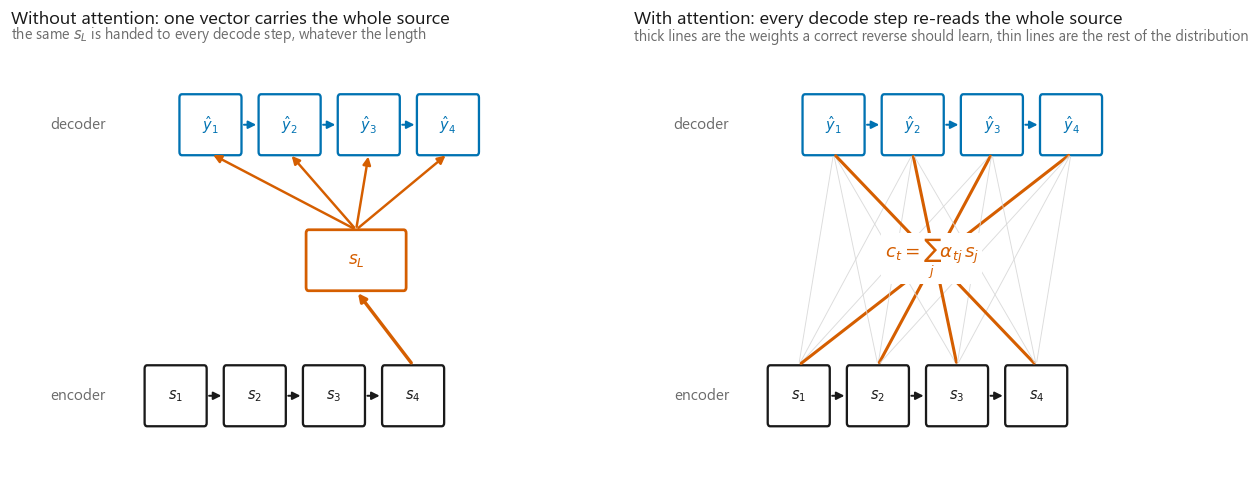

In [5]:
from matplotlib.patches import FancyBboxPatch, Rectangle


def token_row(ax, y, n, colour, prefix, width=0.9, gap=1.25, x0=0.0):
    centres = []
    for i in range(n):
        cx = x0 + i * gap
        ax.add_patch(FancyBboxPatch((cx - width / 2, y - 0.32), width, 0.64,
                                    boxstyle="round,pad=0.04", linewidth=1.5,
                                    edgecolor=colour, facecolor="white", zorder=3))
        ax.text(cx, y, f"${prefix}_{i + 1}$", ha="center", va="center",
                fontsize=9.5, color=colour, zorder=4)
        centres.append(cx)
    return centres


N_BOXES = 4
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))

for ax, uses_attention in zip(axes, [False, True]):
    encoder_x = token_row(ax, 0.0, N_BOXES, style.INK, "s")
    decoder_x = token_row(ax, 3.2, N_BOXES, style.PALETTE[0], r"\hat{y}",
                          x0=0.55)
    for i in range(N_BOXES - 1):
        ax.annotate("", xy=(encoder_x[i + 1] - 0.48, 0.0),
                    xytext=(encoder_x[i] + 0.48, 0.0),
                    arrowprops=dict(arrowstyle="-|>", color=style.INK, lw=1.3))
        ax.annotate("", xy=(decoder_x[i + 1] - 0.48, 3.2),
                    xytext=(decoder_x[i] + 0.48, 3.2),
                    arrowprops=dict(arrowstyle="-|>", color=style.PALETTE[0], lw=1.3))

    if uses_attention:
        for j, sx in enumerate(encoder_x):
            for i, dx in enumerate(decoder_x):
                expected = (N_BOXES - 1 - i) == j
                ax.annotate("", xy=(dx, 2.86), xytext=(sx, 0.36),
                            arrowprops=dict(
                                arrowstyle="-", lw=2.0 if expected else 0.6,
                                color=style.HIGHLIGHT if expected else style.RULE,
                                alpha=1.0 if expected else 0.9))
        ax.text(2.1, 1.62, r"$c_t = \sum_j \alpha_{tj}\, s_j$", ha="center",
                va="center", fontsize=12, color=style.HIGHLIGHT,
                bbox=dict(facecolor="white", edgecolor="none", pad=2))
        headline = "With attention: every decode step re-reads the whole source"
        sub = ("thick lines are the weights a correct reverse should learn, thin "
               "lines are the rest of the distribution")
    else:
        ax.add_patch(FancyBboxPatch((2.1, 1.28), 1.5, 0.64,
                                    boxstyle="round,pad=0.04", linewidth=1.8,
                                    edgecolor=style.HIGHLIGHT, facecolor="white",
                                    zorder=3))
        ax.text(2.85, 1.6, "$s_L$", ha="center", va="center", fontsize=11,
                color=style.HIGHLIGHT, zorder=4)
        ax.annotate("", xy=(2.85, 1.24), xytext=(encoder_x[-1], 0.36),
                    arrowprops=dict(arrowstyle="-|>", color=style.HIGHLIGHT, lw=2.2))
        for dx in decoder_x:
            ax.annotate("", xy=(dx, 2.86), xytext=(2.85, 1.96),
                        arrowprops=dict(arrowstyle="-|>", color=style.HIGHLIGHT,
                                        lw=1.6))
        headline = "Without attention: one vector carries the whole source"
        sub = "the same $s_L$ is handed to every decode step, whatever the length"

    ax.text(-1.1, 0.0, "encoder", ha="right", va="center", fontsize=10,
            color=style.MUTED)
    ax.text(-1.1, 3.2, "decoder", ha="right", va="center", fontsize=10,
            color=style.MUTED)
    ax.set_xlim(-2.6, 5.6)
    ax.set_ylim(-0.9, 4.0)
    ax.axis("off")
    style.title(ax, headline, sub)

style.save(fig, FIG / "fig-01-bottleneck-against-attention.png")

## 3. Training both, at six source lengths

A separate pair of models at each length, each trained only on sequences of that
length. This is deliberate. Training one pair on mixed lengths would blur two
questions together: whether the architecture can handle a long source, and
whether it generalises from short training examples to long ones. The first
question is the one attention was introduced to answer, so each length gets its
own model and its own fresh initialisation.

Everything else is held fixed: the same hidden size, the same embedding, the same
optimiser, the same number of gradient steps, the same seed. The parameter counts
are printed below and they differ only by the three small attention matrices.

In [6]:
from torch.utils.data import TensorDataset, DataLoader

LENGTHS = [3, 6, 9, 12, 16, 20]
N_TRAIN, N_TEST = 4096, 1024
EPOCHS, BATCH, LR = 18, 128, 3e-3


def batches(source, decoder_input, target, batch=BATCH, shuffle=True, seed=SEED):
    dataset = TensorDataset(torch.tensor(source), torch.tensor(decoder_input),
                            torch.tensor(target))
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(dataset, batch_size=batch, shuffle=shuffle,
                      generator=generator if shuffle else None)


def train(model, loader, epochs=EPOCHS, lr=LR, clip=1.0):
    """Teacher forcing throughout, which is how these models are always trained."""
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(epochs):
        model.train()
        running, seen = 0.0, 0
        for src, dec_in, tgt in loader:
            src, dec_in, tgt = src.to(device), dec_in.to(device), tgt.to(device)
            optimiser.zero_grad()
            logits, _ = model(src, dec_in)
            loss = loss_fn(logits.reshape(-1, VOCAB), tgt.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimiser.step()
            running += float(loss) * len(src)
            seen += len(src)
        curve.append(running / seen)
    return curve


@torch.no_grad()
def evaluate(model, source, decoder_input, target):
    """Token and sequence accuracy under teacher forcing and under free running."""
    model.eval()
    src = torch.tensor(source).to(device)
    dec_in = torch.tensor(decoder_input).to(device)
    tgt = torch.tensor(target).to(device)

    forced, _ = model(src, dec_in)
    forced_correct = (forced.argmax(-1) == tgt)

    free, attention_map = model(src, steps=source.shape[1])
    free_correct = (free.argmax(-1) == tgt)

    return {
        "teacher forced token": float(forced_correct.float().mean()),
        "teacher forced sequence": float(forced_correct.all(dim=1).float().mean()),
        "free running token": float(free_correct.float().mean()),
        "free running sequence": float(free_correct.all(dim=1).float().mean()),
    }, free_correct.cpu().numpy(), attention_map


MODELS = [("no attention", False, style.NEUTRAL),
          ("attention", True, style.HIGHLIGHT)]

for name, uses_attention, _ in MODELS:
    torch.manual_seed(SEED)
    model = Seq2Seq(attention=uses_attention)
    print(f"{name:<13} {sum(p.numel() for p in model.parameters()):,} parameters")

no attention  176,169 parameters
attention     192,617 parameters


In [7]:
results, trained, test_sets, curves = [], {}, {}, {}

started_all = time.perf_counter()
for length in LENGTHS:
    rng = np.random.default_rng(SEED + length)
    train_set = make_reverse_task(N_TRAIN, length, rng)
    test_set = make_reverse_task(N_TEST, length, rng)
    test_sets[length] = test_set
    loader = batches(*train_set)

    for name, uses_attention, _ in MODELS:
        torch.manual_seed(SEED)
        model = Seq2Seq(attention=uses_attention).to(device)
        started = time.perf_counter()
        curves[(name, length)] = train(model, loader)
        scores, _, _ = evaluate(model, *test_set)
        trained[(name, length)] = model
        results.append({"length": length, "model": name,
                        "final loss": round(curves[(name, length)][-1], 4),
                        **{k: round(v, 4) for k, v in scores.items()},
                        "seconds": round(time.perf_counter() - started, 1)})

    row = {r["model"]: r for r in results[-2:]}
    print(f"length {length:>3}   "
          f"no attention {row['no attention']['free running sequence']:.3f}   "
          f"attention {row['attention']['free running sequence']:.3f}   "
          f"(free-running sequence accuracy)")

sweep = pd.DataFrame(results)
print(f"\ntrained {len(LENGTHS) * len(MODELS)} models in "
      f"{time.perf_counter() - started_all:.0f} s\n")
print(sweep.to_string(index=False))

C:\Users\pilot\AppData\Local\Temp\ipykernel_29104\2930713758.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  running += float(loss) * len(src)


length   3   no attention 1.000   attention 1.000   (free-running sequence accuracy)


length   6   no attention 0.924   attention 1.000   (free-running sequence accuracy)


length   9   no attention 0.747   attention 1.000   (free-running sequence accuracy)


length  12   no attention 0.327   attention 0.953   (free-running sequence accuracy)


length  16   no attention 0.035   attention 0.875   (free-running sequence accuracy)


length  20   no attention 0.000   attention 0.871   (free-running sequence accuracy)

trained 12 models in 302 s

 length        model  final loss  teacher forced token  teacher forced sequence  free running token  free running sequence  seconds
      3 no attention      0.0002                1.0000                   1.0000              1.0000                 1.0000     11.7
      3    attention      0.0000                1.0000                   1.0000              1.0000                 1.0000     10.2
      6 no attention      0.0317                0.9873                   0.9238              0.9772                 0.9238     10.4
      6    attention      0.0001                1.0000                   1.0000              1.0000                 1.0000     15.1
      9 no attention      0.0704                0.9693                   0.7471              0.9353                 0.7471     13.8
      9    attention      0.0004                1.0000                   1.0000              1

## 4. Where the bottleneck gives way

Sequence accuracy is the strict measure: every token of the output has to be
right. Token accuracy is the forgiving one. Both are worth plotting because the
gap between them says whether a model is failing everywhere or failing in one
place per sequence.

 length  no attention, sequence  attention, sequence   gap  no attention, token  attention, token
      3                   1.000                1.000 0.000                1.000             1.000
      6                   0.924                1.000 0.076                0.977             1.000
      9                   0.747                1.000 0.253                0.935             1.000
     12                   0.327                0.953 0.626                0.786             0.983
     16                   0.035                0.875 0.840                0.594             0.951
     20                   0.000                0.871 0.871                0.468             0.948

no attention  longest source solved at 50% sequence accuracy: 9
              at length 20: 0.000 sequence, 0.468 token

attention     longest source solved at 50% sequence accuracy: 20
              at length 20: 0.871 sequence, 0.948 token


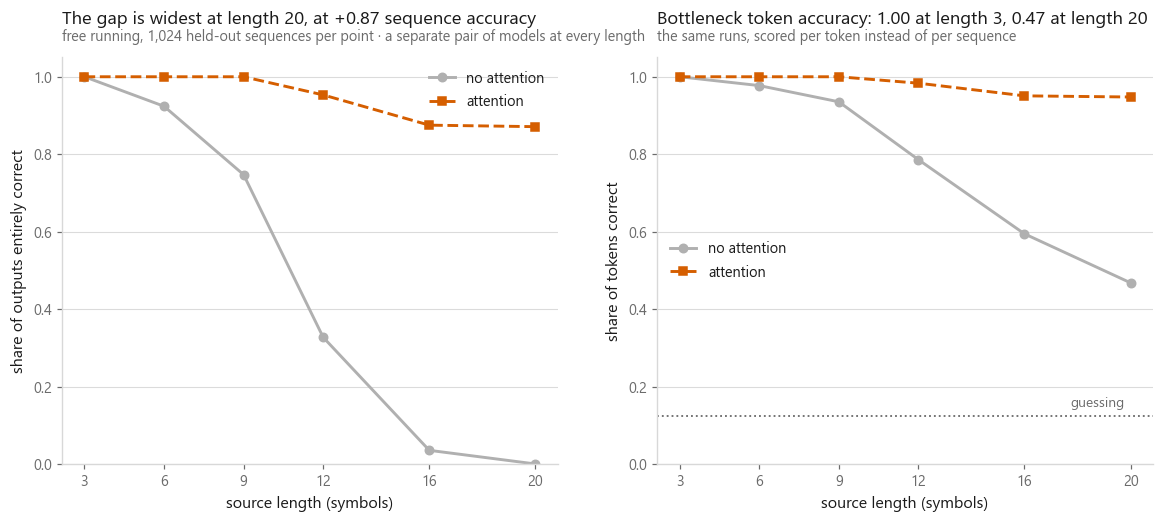

In [8]:
def series(model_name, column):
    rows = sweep[sweep["model"] == model_name].sort_values("length")
    return rows[column].to_numpy()


fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

for i, (name, _, colour) in enumerate(MODELS):
    axes[0].plot(LENGTHS, series(name, "free running sequence"),
                 marker=style.MARKERS[i], color=colour,
                 linestyle=style.DASHES[i], label=name)
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(LENGTHS)
axes[0].set_xlabel("source length (symbols)")
axes[0].set_ylabel("share of outputs entirely correct")
axes[0].legend()

no_attention_seq = series("no attention", "free running sequence")
attention_seq = series("attention", "free running sequence")
gaps = attention_seq - no_attention_seq
widest = LENGTHS[int(np.argmax(gaps))]
style.title(axes[0],
            f"The gap is widest at length {widest}, at "
            f"{gaps.max():+.2f} sequence accuracy",
            f"free running, {N_TEST:,} held-out sequences per point · a separate "
            f"pair of models at every length")

for i, (name, _, colour) in enumerate(MODELS):
    axes[1].plot(LENGTHS, series(name, "free running token"),
                 marker=style.MARKERS[i], color=colour,
                 linestyle=style.DASHES[i], label=name)
axes[1].axhline(1 / N_SYMBOLS, color=style.MUTED, linestyle=":", linewidth=1.2)
axes[1].annotate("guessing", xy=(LENGTHS[-1], 1 / N_SYMBOLS), xytext=(-4, 6),
                 textcoords="offset points", ha="right", fontsize=9,
                 color=style.MUTED)
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(LENGTHS)
axes[1].set_xlabel("source length (symbols)")
axes[1].set_ylabel("share of tokens correct")
axes[1].legend()
no_attention_token = series("no attention", "free running token")
style.title(axes[1],
            f"Bottleneck token accuracy: {no_attention_token[0]:.2f} at length "
            f"{LENGTHS[0]}, {no_attention_token[-1]:.2f} at length {LENGTHS[-1]}",
            "the same runs, scored per token instead of per sequence")

style.save(fig, FIG / "fig-02-length-sweep.png")

comparison = pd.DataFrame({
    "length": LENGTHS,
    "no attention, sequence": no_attention_seq.round(3),
    "attention, sequence": attention_seq.round(3),
    "gap": gaps.round(3),
    "no attention, token": no_attention_token.round(3),
    "attention, token": series("attention", "free running token").round(3),
})
print(comparison.to_string(index=False))

THRESHOLD = 0.5
for name in ("no attention", "attention"):
    values = series(name, "free running sequence")
    passed = [length for length, v in zip(LENGTHS, values) if v >= THRESHOLD]
    print(f"\n{name:<13} longest source solved at {THRESHOLD:.0%} sequence "
          f"accuracy: {max(passed) if passed else 'none'}")
    print(f"{'':<13} at length {LENGTHS[-1]}: {values[-1]:.3f} sequence, "
          f"{series(name, 'free running token')[-1]:.3f} token")

Read the table before the chart. The column to follow is the gap: it says at
which length the two architectures stop being interchangeable, which is the
number this notebook exists to produce.

One honest note about the short end. At the shortest source there is no reason
for attention to help, because the summary vector has plenty of room for three
symbols, and any difference there is initialisation noise rather than
architecture. Attention is a fix for a problem that only exists at length, and if
it shows an advantage at the short end I would want more seeds before believing
it.

### What the outputs actually look like

Averages hide the failure mode. Here is the longest source in the sweep, with
both models decoding the same held-out sequences.

In [9]:
LOOK_AT = LENGTHS[-1]
src, dec_in, tgt = test_sets[LOOK_AT]

decoded = {}
for name, _, _ in MODELS:
    with torch.no_grad():
        free, _ = trained[(name, LOOK_AT)](torch.tensor(src).to(device),
                                           steps=LOOK_AT)
    decoded[name] = free.argmax(-1).cpu().numpy()

print(f"source length {LOOK_AT}, three held-out sequences, free running\n")
for row in range(3):
    print(f"source        {src[row]}")
    print(f"correct       {tgt[row]}")
    for name, _, _ in MODELS:
        hits = int((decoded[name][row] == tgt[row]).sum())
        print(f"{name:<13} {decoded[name][row]}   {hits}/{LOOK_AT} right")
    print()

position_hits = {
    name: (decoded[name] == tgt).mean(axis=0) for name, _, _ in MODELS}
print("share correct by output position (position 1 is the first token emitted):")
print(pd.DataFrame({"position": np.arange(1, LOOK_AT + 1),
                    **{name: np.round(v, 3) for name, v in position_hits.items()}}
                   ).to_string(index=False))

source length 20, three held-out sequences, free running

source        [6 2 3 1 5 3 7 1 1 1 2 2 7 5 8 8 5 2 2 7]
correct       [7 2 2 5 8 8 5 7 2 2 1 1 1 7 3 5 1 3 2 6]
no attention  [7 2 2 5 8 8 7 2 5 1 5 1 2 7 3 1 1 2 6 3]   10/20 right
attention     [7 2 2 5 8 8 5 7 2 2 1 1 1 7 3 5 1 3 2 6]   20/20 right

source        [1 4 2 2 8 8 6 2 3 7 3 2 2 1 7 2 7 3 8 1]
correct       [1 8 3 7 2 7 1 2 2 3 7 3 2 6 8 8 2 2 4 1]
no attention  [1 8 3 7 7 2 1 2 2 3 2 3 7 6 8 2 8 4 1 2]   11/20 right
attention     [1 8 3 7 2 7 1 2 2 3 7 3 2 6 8 8 2 2 4 1]   20/20 right

source        [7 6 4 1 4 6 8 6 7 3 2 5 5 1 2 3 1 3 5 4]
correct       [4 5 3 1 3 2 1 5 5 2 3 7 6 8 6 4 1 4 6 7]
no attention  [4 5 3 1 3 2 5 1 7 5 2 6 3 4 1 8 6 6 4 7]   7/20 right
attention     [4 5 3 1 3 2 1 5 5 2 3 7 6 8 6 4 1 4 6 7]   20/20 right

share correct by output position (position 1 is the first token emitted):
 position  no attention  attention
        1         0.946      0.997
        2         0.859      0.996
     

The per-position table is the most informative thing in this section. For a
reverse task the decoder's first output corresponds to the *last* source symbol,
which is the one the encoder saw most recently and therefore the one its final
state remembers best. So a bottleneck model should do best at the start of the
output and worst at the end, and the shape of that column says whether it does.

## 5. Teacher forcing against free running

Every model above was trained with **teacher forcing**: at each decoder step it
was handed the correct previous token, not its own. That is standard, and it is
the reason these models train at all, because without it an early mistake
corrupts every step after it and the gradient signal is noise for most of
training.

The problem is that it is also the easiest way to evaluate, and evaluating that
way answers a question nobody asked. At use time there are no correct previous
tokens. The model consumes what it produced, mistakes included, and the
distribution of inputs it sees at step $t$ is not the one it was trained on. That
mismatch has a name, **exposure bias**, and the size of it is the difference
between the two columns below.

 length  no attention gap  attention gap
      3             0.000          0.000
      6             0.010          0.000
      9             0.034          0.000
     12             0.128          0.012
     16             0.234          0.037
     20             0.291          0.040

no attention  largest teacher-forcing gap 0.291 at length 20

attention     largest teacher-forcing gap 0.040 at length 20


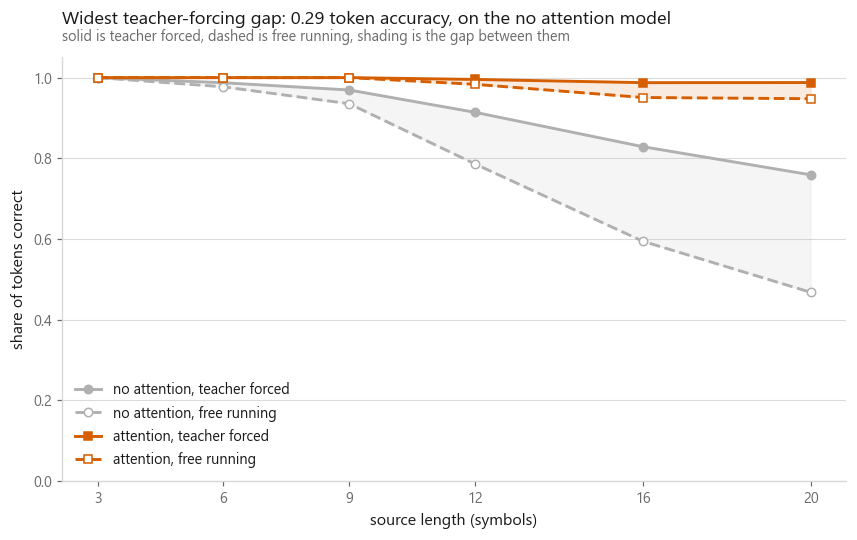

In [10]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))

for i, (name, _, colour) in enumerate(MODELS):
    ax.plot(LENGTHS, series(name, "teacher forced token"), marker=style.MARKERS[i],
            color=colour, linestyle="-", label=f"{name}, teacher forced")
    ax.plot(LENGTHS, series(name, "free running token"), marker=style.MARKERS[i],
            color=colour, linestyle="--", markerfacecolor="white",
            label=f"{name}, free running")
    ax.fill_between(LENGTHS, series(name, "free running token"),
                    series(name, "teacher forced token"), color=colour, alpha=0.12)

ax.set_ylim(0, 1.05)
ax.set_xticks(LENGTHS)
ax.set_xlabel("source length (symbols)")
ax.set_ylabel("share of tokens correct")
ax.legend()

forcing_gap = {name: series(name, "teacher forced token")
               - series(name, "free running token") for name, _, _ in MODELS}
worst = max(forcing_gap, key=lambda k: forcing_gap[k].max())
style.title(ax,
            f"Widest teacher-forcing gap: {forcing_gap[worst].max():.2f} token "
            f"accuracy, on the {worst} model",
            "solid is teacher forced, dashed is free running, shading is the gap "
            "between them")
style.save(fig, FIG / "fig-03-teacher-forcing.png")

gap_table = pd.DataFrame({"length": LENGTHS,
                          **{f"{name} gap": np.round(v, 3)
                             for name, v in forcing_gap.items()}})
print(gap_table.to_string(index=False))
for name, values in forcing_gap.items():
    print(f"\n{name:<13} largest teacher-forcing gap {values.max():.3f} "
          f"at length {LENGTHS[int(np.argmax(values))]}")

The shaded band is the number that goes missing from most reported results. A
teacher-forced score is a measurement of a model that will never be run that
way, and the wider the band the less the reported number tells you about
behaviour in use.

There is a structural reason to expect the band to widen with length: an error
at step $t$ under free running feeds every step after it, so a longer output has
more steps in which one mistake can compound. The printed table says whether it
did here, and for which model.

Two things narrow the band in practice. **Scheduled sampling** feeds the model's
own token instead of the correct one with a probability that rises during
training, so the training distribution drifts towards the one it will meet.
**Beam search** keeps several candidate outputs alive at once instead of
committing to the argmax at every step, which reduces how often one bad token
derails the rest. Neither is in this notebook, because both of them change the
number I am trying to measure.

## 6. Reading the alignment, then scoring it

The attention matrix is $\alpha$, one row per decode step and one column per
source position, every row summing to one. For a reverse task the correct row
$t$ puts all its weight on source position $L - t$, so the matrix of a working
model has to be an anti-diagonal. Nothing in the loss says so. The model is only
ever told whether its output tokens were right.

In [11]:
ALIGN_LENGTH = LENGTHS[-1]
align_src, align_in, align_tgt = test_sets[ALIGN_LENGTH]
attention_model = trained[("attention", ALIGN_LENGTH)]

with torch.no_grad():
    _, maps = attention_model(torch.tensor(align_src).to(device), steps=ALIGN_LENGTH)
maps = maps.cpu().numpy()                      # (B, decode steps, source positions)

expected = ALIGN_LENGTH - 1 - np.arange(ALIGN_LENGTH)      # anti-diagonal
argmax_position = maps.argmax(axis=2)
hit_rate = float((argmax_position == expected[None, :]).mean())
mean_offset = float(np.abs(argmax_position - expected[None, :]).mean())
entropy = float(-(maps * np.log(maps + 1e-12)).sum(axis=2).mean())
uniform_entropy = float(np.log(ALIGN_LENGTH))
peak_weight = float(maps.max(axis=2).mean())

print(f"source length {ALIGN_LENGTH}, {maps.shape[0]:,} held-out sequences")
print(f"decode steps whose heaviest weight is on the expected position: "
      f"{hit_rate:.3f}")
print(f"chance if the argmax were placed at random                    : "
      f"{1 / ALIGN_LENGTH:.3f}")
print(f"mean distance from the expected position (in symbols)         : "
      f"{mean_offset:.2f}")
print(f"mean weight on the heaviest position                          : "
      f"{peak_weight:.3f}")
print(f"attention entropy {entropy:.3f} against {uniform_entropy:.3f} for uniform "
      f"({entropy / uniform_entropy:.1%} of it)")

source length 20, 1,024 held-out sequences
decode steps whose heaviest weight is on the expected position: 0.080
chance if the argmax were placed at random                    : 0.050
mean distance from the expected position (in symbols)         : 0.97
mean weight on the heaviest position                          : 0.880
attention entropy 0.491 against 2.996 for uniform (16.4% of it)


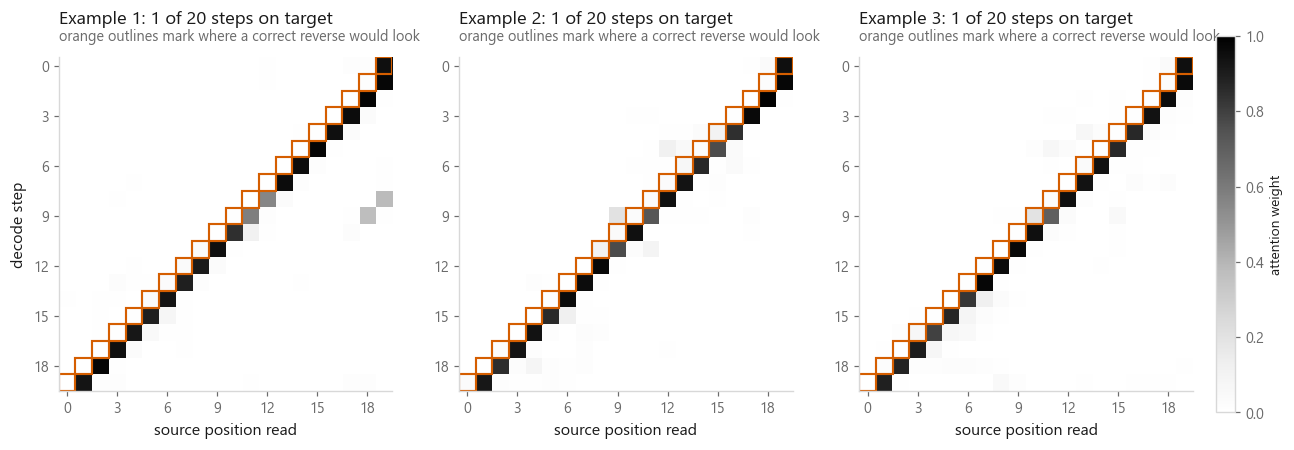

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.9))

for panel, (ax, example) in enumerate(zip(axes, [0, 1, 2])):
    image = ax.imshow(maps[example], cmap="Greys", aspect="equal",
                      interpolation="nearest", vmin=0, vmax=1)
    # Second channel beside colour: outline the cell a correct reverse would use.
    for t, j in enumerate(expected):
        ax.add_patch(Rectangle((j - 0.5, t - 0.5), 1, 1, fill=False,
                               edgecolor=style.HIGHLIGHT, linewidth=1.4))
    ax.set_xticks(range(0, ALIGN_LENGTH, 3))
    ax.set_yticks(range(0, ALIGN_LENGTH, 3))
    ax.grid(False)
    ax.set_xlabel("source position read")
    if panel == 0:
        ax.set_ylabel("decode step")
    hits = int((argmax_position[example] == expected).sum())
    style.title(ax, f"Example {example + 1}: {hits} of {ALIGN_LENGTH} steps on target",
                "orange outlines mark where a correct reverse would look")

fig.colorbar(image, ax=axes, fraction=0.016, pad=0.02).set_label(
    "attention weight", fontsize=9)
style.save(fig, FIG / "fig-04-attention-maps.png")

Nobody supervised those weights. The loss never mentioned source positions, only
output tokens, so whatever structure the panels show is what minimising that
loss produced on its own. If the weights follow the orange outlines, the model
found the cheapest way to reverse a sequence, which is to read it backwards.

That is the property worth taking away from attention, and it survives into the
Transformer: a mechanism trained only on the end task produces an intermediate
quantity you can plot and argue with. It is not an explanation of the model, and
treating an attention map as one is a known trap. It is a record of which inputs
were mixed into which step, which is a narrower and more reliable claim.

### Does the alignment survive the length sweep?

The same three numbers computed for every length, so the picture above becomes a
curve.

In [13]:
alignment_rows = []
for length in LENGTHS:
    source, _, _ = test_sets[length]
    with torch.no_grad():
        _, maps_l = trained[("attention", length)](
            torch.tensor(source).to(device), steps=length)
    maps_l = maps_l.cpu().numpy()
    expected_l = length - 1 - np.arange(length)
    argmax_l = maps_l.argmax(axis=2)
    alignment_rows.append({
        "length": length,
        "on target": round(float((argmax_l == expected_l[None, :]).mean()), 3),
        "chance": round(1 / length, 3),
        "mean offset": round(float(np.abs(argmax_l - expected_l[None, :]).mean()), 2),
        "peak weight": round(float(maps_l.max(axis=2).mean()), 3),
        "entropy / uniform": round(
            float(-(maps_l * np.log(maps_l + 1e-12)).sum(axis=2).mean()
                  / np.log(length)), 3),
    })

alignment = pd.DataFrame(alignment_rows)
print(alignment.to_string(index=False))

 length  on target  chance  mean offset  peak weight  entropy / uniform
      3      1.000   0.333         0.00        0.794              0.464
      6      0.959   0.167         0.04        0.619              0.509
      9      0.245   0.111         0.76        0.520              0.542
     12      0.094   0.083         0.93        0.820              0.262
     16      0.105   0.062         0.91        0.863              0.185
     20      0.080   0.050         0.97        0.880              0.164


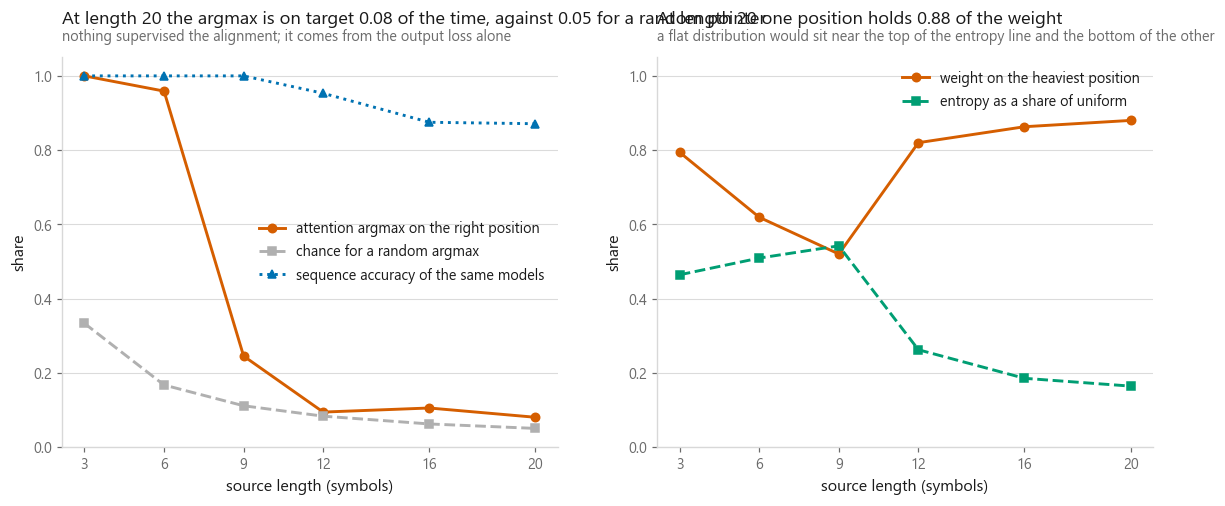

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))

axes[0].plot(alignment["length"], alignment["on target"], marker=style.MARKERS[0],
             color=style.HIGHLIGHT, label="attention argmax on the right position")
axes[0].plot(alignment["length"], alignment["chance"], marker=style.MARKERS[1],
             color=style.NEUTRAL, linestyle="--", label="chance for a random argmax")
axes[0].plot(LENGTHS, attention_seq, marker=style.MARKERS[2],
             color=style.PALETTE[0], linestyle=":",
             label="sequence accuracy of the same models")
axes[0].set_ylim(0, 1.05)
axes[0].set_xticks(LENGTHS)
axes[0].set_xlabel("source length (symbols)")
axes[0].set_ylabel("share")
axes[0].legend()
final_on_target = float(alignment["on target"].iloc[-1])
final_chance = float(alignment["chance"].iloc[-1])
style.title(axes[0],
            f"At length {LENGTHS[-1]} the argmax is on target "
            f"{final_on_target:.2f} of the time, against {final_chance:.2f} "
            f"for a random pointer",
            "nothing supervised the alignment; it comes from the output loss "
            "alone")

axes[1].plot(alignment["length"], alignment["peak weight"], marker=style.MARKERS[0],
             color=style.HIGHLIGHT, label="weight on the heaviest position")
axes[1].plot(alignment["length"], alignment["entropy / uniform"],
             marker=style.MARKERS[1], color=style.PALETTE[2], linestyle="--",
             label="entropy as a share of uniform")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(LENGTHS)
axes[1].set_xlabel("source length (symbols)")
axes[1].set_ylabel("share")
axes[1].legend()
style.title(axes[1],
            f"At length {LENGTHS[-1]} one position holds "
            f"{alignment['peak weight'].iloc[-1]:.2f} of the weight",
            "a flat distribution would sit near the top of the entropy line and "
            "the bottom of the other")

style.save(fig, FIG / "fig-05-alignment-scores.png")

The entropy line is the one that catches a model faking it. Attention weights
that stay near uniform mean the context vector is an average of the whole source,
which is a smoother version of the bottleneck rather than a fix for it. A low
entropy with a high on-target rate is a model that is genuinely addressing
positions.

## 7. What this buys, and what it costs

The length sweep in section 4 is the case for attention, in whichever direction
its gap column runs. What belongs next to it is the price.

**Cost in arithmetic.** Attention compares every decode step against every source
position, so the work is $O(L_{\text{source}} \times L_{\text{target}})$ where the
bottleneck decoder was $O(L_{\text{target}})$. On a twenty-symbol toy that is
nothing. On documents it is the reason people care about efficient attention.

**Cost in memory.** The encoder states all have to be kept for the whole decode,
instead of one summary vector.

**What it does not cost.** The parameter count barely moved, as the two numbers
printed in section 3 show. Attention is not a bigger model. It is a different
route to the same encoder states.

And the thing it removes is the reason [09-07](../07-transformer-from-scratch/)
exists. Once every decode step can see every source position directly, the
recurrence is doing less and less of the work of moving information around. The
Transformer's question is whether the recurrence is needed at all, and the answer
it gives is to attend from every position to every other position, drop the loop,
and get back the parallelism that section 2 said no library could fuse.

final teacher-forced training loss
 length  no attention  attention
      3        0.0002     0.0000
      6        0.0317     0.0001
      9        0.0704     0.0004
     12        0.1814     0.0222
     16        0.3876     0.0424
     20        0.5611     0.0717

a model that guessed uniformly would sit at 2.0794


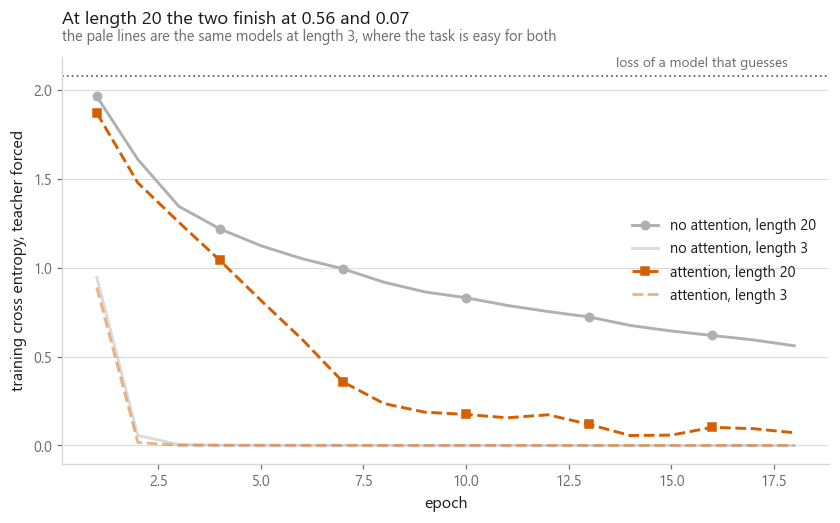

In [15]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))

for i, (name, _, colour) in enumerate(MODELS):
    ax.plot(np.arange(1, EPOCHS + 1), curves[(name, LENGTHS[-1])],
            color=colour, marker=style.MARKERS[i], markevery=3,
            linestyle=style.DASHES[i], label=f"{name}, length {LENGTHS[-1]}")
    ax.plot(np.arange(1, EPOCHS + 1), curves[(name, LENGTHS[0])],
            color=colour, alpha=0.45, linestyle=style.DASHES[i],
            label=f"{name}, length {LENGTHS[0]}")
ax.axhline(np.log(N_SYMBOLS), color=style.MUTED, linestyle=":", linewidth=1.2)
ax.annotate("loss of a model that guesses", xy=(EPOCHS, np.log(N_SYMBOLS)),
            xytext=(-4, 6), textcoords="offset points", ha="right",
            fontsize=9, color=style.MUTED)
ax.set_xlabel("epoch")
ax.set_ylabel("training cross entropy, teacher forced")
ax.legend()
final_long = {name: curves[(name, LENGTHS[-1])][-1] for name, _, _ in MODELS}
style.title(ax,
            f"At length {LENGTHS[-1]} the two finish at "
            f"{final_long['no attention']:.2f} and {final_long['attention']:.2f}",
            f"the pale lines are the same models at length {LENGTHS[0]}, where "
            f"the task is easy for both")
style.save(fig, FIG / "fig-06-training-curves.png")

print("final teacher-forced training loss")
print(pd.DataFrame([{"length": length,
                     **{name: round(curves[(name, length)][-1], 4)
                        for name, _, _ in MODELS}}
                    for length in LENGTHS]).to_string(index=False))
print(f"\na model that guessed uniformly would sit at {np.log(N_SYMBOLS):.4f}")

The training loss is worth a look because it separates two different failures.
A model whose training loss stays near the guessing line never learned the task
at all. A model whose training loss falls but whose free-running accuracy does
not follow has learned the task under teacher forcing and cannot execute it on
its own output, which is section 5's gap showing up from the other side.

## Cheat sheet

| | |
|---|---|
| **Encoder-decoder** | Encoder GRU reads the source, decoder GRU writes the target. The decoder loop cannot be fused, because step $t$ needs step $t-1$'s output |
| **The bottleneck** | Without attention the decoder sees one fixed-size summary of the source, whatever the source length |
| **Additive attention** | $e_{tj} = v^\top \tanh(W_d h_{t-1} + W_e s_j)$, softmax over $j$, then $c_t = \sum_j \alpha_{tj} s_j$ |
| **Dot-product attention** | $e_{tj} = h_{t-1}^\top s_j / \sqrt{d}$. No parameters, and what the Transformer uses |
| **Precompute** | $W_e s_j$ does not depend on the decode step. Computing it inside the loop is the standard way to make attention slow |
| **Context** | A convex combination of encoder states, so its norm is bounded by theirs. Attention blends, it does not invent |
| **Teacher forcing** | Feed the correct previous token during training. Necessary to train, and misleading if you also evaluate that way |
| **Exposure bias** | The gap between teacher-forced and free-running scores. Report both |
| **Reading $\alpha$** | A distribution over source positions per decode step. Plot it, and score it against a known alignment when you have one |
| **Entropy check** | Near-uniform weights mean attention is averaging rather than addressing. Compare against $\log L$ |
| **Cost** | $O(L_{\text{src}} \times L_{\text{tgt}})$ arithmetic and all the encoder states kept in memory, for almost no extra parameters |
| **Next** | [The Transformer](../07-transformer-from-scratch/), which keeps the attention and throws away the recurrence |

## What to remember

1. An encoder-decoder without attention has to squeeze the whole source into one
   fixed-size vector. The sweep over source length is how you find out when that
   stops working, and the printed gap column is the answer for this task.
2. Attention replaces that one vector with a fresh weighted average of every
   encoder state, recomputed at every decode step.
3. The weights are a probability distribution over source positions, which makes
   them plottable, and on a task with a known correct alignment, scorable.
4. Nothing supervises the alignment. It comes out of the output loss alone,
   which is the property that carries over to the Transformer.
5. Score the attention rather than admiring it. On-target rate against chance,
   and entropy against $\log L$, separate a model that addresses positions from
   one that averages everything.
6. Precompute the encoder-side projection outside the decoding loop.
7. Teacher forcing during training is standard and necessary. Teacher forcing
   during evaluation reports a number for a model nobody will run. Print both and
   print the gap.
8. Attention costs arithmetic and memory that grow with the product of the two
   lengths, and almost no parameters. It is a routing change, not a capacity one.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-07 The Transformer, built from scratch](../07-transformer-from-scratch/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Attention` `#Seq2Seq` `#PyTorch` `#NLP`
`#MachineLearning` `#Python` `#MLTutorial` `#LearnMachineLearning` `#AI`